In [1]:
#imports

import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import AdamW
from CNO1D_def import CNO1D
import matplotlib.pyplot as plt
import h5py
import time

torch.manual_seed(0)
np.random.seed(0)

In [2]:
path = "/scratch/mnhagen/datasets/heat1d_multires/heat1D_autoreg_N128_multi.h5"

with h5py.File(path, "r") as f:
    u = f["u"][:]
    X = f["X"][:]

print(u.shape)

x_data = torch.tensor(u[:, 0, :], dtype=torch.float32)[:, None, :]
y_data = torch.tensor(u[:, 1, :], dtype=torch.float32)[:, None, :]

(1000, 2, 128)


In [ ]:
train_ratio = 0.8
val_patience = 25

# Load the data
s = x_data.shape[-1]
num_samples = x_data.shape[0]
n_train = int(num_samples * train_ratio)

x_data = F.interpolate(x_data, size = s, mode = "linear", align_corners= False)
y_data = F.interpolate(y_data, size = s, mode = "linear", align_corners= False)


input_function_train = x_data[:n_train]
output_function_train = y_data[:n_train]
input_function_test = x_data[n_train:]
output_function_test = y_data[n_train:]

batch_size = 10

train_loader = DataLoader(TensorDataset(input_function_train, output_function_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(input_function_test, output_function_test), batch_size=batch_size, shuffle=False)


#---------------------
# Define the hyperparameters and the model:
#---------------------

learning_rate = 1e-3
epochs = 500
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
time_loss = np.zeros((2,epochs))


N_layers = 4
N_res    = 4
N_res_neck = 4
channel_multiplier = 16

In [10]:
#-----------
# TRAIN:
#-----------

model = CNO1D(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = s,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = False)

model.to(device)
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-8)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
step_size = 15
gamma = 0.5
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

criterion = torch.nn.MSELoss()
use_patience = True
freq_print = 1
epochs_no_improve = 0
best_val_loss = 1e12
start_time = time.time()
for epoch in range(epochs):
    print("LR at epoch start:", optimizer.param_groups[0]["lr"])
    model.train()
    train_mse = 0.0

    for step, (input_batch, output_batch) in enumerate(train_loader):
        input_batch = input_batch.to(device)
        output_batch = output_batch.to(device)

        optimizer.zero_grad()
        output_pred_batch = model(input_batch)
        loss_f = criterion(output_pred_batch, output_batch)
        loss_f.backward()
        optimizer.step()
        train_mse += loss_f.item()
    train_mse /= len(train_loader)

    scheduler.step()

    #Validation
    with torch.no_grad():
        model.eval()
        val_loss = 0.0
        for step, (input_batch, output_batch) in enumerate(val_loader):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)

            output_pred_batch = model(input_batch)
            val_loss += F.mse_loss(output_pred_batch, output_batch).item()
        val_loss /= len(val_loader)

    if epoch % freq_print == 0: print(f"Epoch {epoch:03d} | Train {train_mse:.4e} | Val {val_loss:.4e}")

    # Early stopping
    if use_patience:
        if val_loss < best_val_loss * (1 - 1e-3):
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0

        else:
            if best_val_loss * (1 - 1e-3) < val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve += 1
            if epochs_no_improve >= val_patience:
                print("Early stop triggered.")
                break

    time_loss[0][epoch] = time.time() - start_time
    time_loss[1][epoch] = val_loss

time_loss = time_loss[:, :epoch]
model.load_state_dict(best_state)

print("Training complete. Best val loss:", best_val_loss)

LR at epoch start: 0.001
Epoch 000 | Train 1.6136e-02 | Val 1.8804e-03
LR at epoch start: 0.001
Epoch 001 | Train 1.6410e-03 | Val 1.1859e-03
LR at epoch start: 0.001
Epoch 002 | Train 1.2529e-03 | Val 1.0493e-03
LR at epoch start: 0.001
Epoch 003 | Train 1.1198e-03 | Val 8.7633e-04
LR at epoch start: 0.001
Epoch 004 | Train 1.0049e-03 | Val 7.1861e-04
LR at epoch start: 0.001
Epoch 005 | Train 8.3102e-04 | Val 7.5257e-04
LR at epoch start: 0.001
Epoch 006 | Train 6.9669e-04 | Val 7.8597e-04
LR at epoch start: 0.001
Epoch 007 | Train 5.6131e-04 | Val 4.6746e-04
LR at epoch start: 0.001
Epoch 008 | Train 5.7434e-04 | Val 5.0805e-04
LR at epoch start: 0.001
Epoch 009 | Train 3.0761e-04 | Val 1.7868e-04
LR at epoch start: 0.001
Epoch 010 | Train 1.0750e-04 | Val 1.0327e-04
LR at epoch start: 0.001
Epoch 011 | Train 6.2638e-05 | Val 4.2359e-05
LR at epoch start: 0.001
Epoch 012 | Train 5.5915e-05 | Val 4.3754e-05
LR at epoch start: 0.001
Epoch 013 | Train 3.6372e-05 | Val 3.5735e-05
LR at 

In [11]:
#directory definition

model_dir = "/scratch/mnhagen/models/heat1d"
model_name = "CNO1D_heat1d_N128_stepLR"
model_loss_name = model_name + "_loss"
model_path = os.path.join(model_dir, model_name + ".pt")
model_loss_path = os.path.join(model_dir, model_loss_name + ".csv")

In [12]:
#Save model

overwrite = True

os.makedirs(model_dir, exist_ok= True)

if not overwrite:
    if os.path.exists(model_path):
        raise FileExistsError(f"Model file already exists: {model_path}")

torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

np.savetxt(
    model_loss_path,
    time_loss,
    delimiter=",",
    fmt="%.6f"   # controls number formatting
)
print(f"Model loss saved to {model_loss_path}")

Model saved to /scratch/mnhagen/models/heat1d/CNO1D_heat1d_N128_stepLR.pt
Model loss saved to /scratch/mnhagen/models/heat1d/CNO1D_heat1d_N128_stepLR_loss.csv


In [8]:
#load model

model = CNO1D(in_dim = 1,                                    # Number of input channels.
            out_dim = 1,                                   # Number of input channels.
            size = s,                                      # Input and Output spatial size (required )
            N_layers = N_layers,                           # Number of (D) or (U) blocks in the network
            N_res = N_res,                                 # Number of (R) blocks per level (except the neck)
            N_res_neck = N_res_neck,                       # Number of (R) blocks in the neck
            channel_multiplier = channel_multiplier,       # How the number of channels evolve?
            use_bn = False)

model.load_state_dict(torch.load(model_path))
model.eval()
model_name = "CNO1D_heat1d_N128"

l = nn.L1Loss()
print(f"Loaded model from {model_path}")

Loaded model from /scratch/mnhagen/models/heat1d/CNO1D_heat1d_N128.pt


torch.Size([200, 1, 128])
torch.Size([1])
(128,)
torch.Size([200, 1, 128])


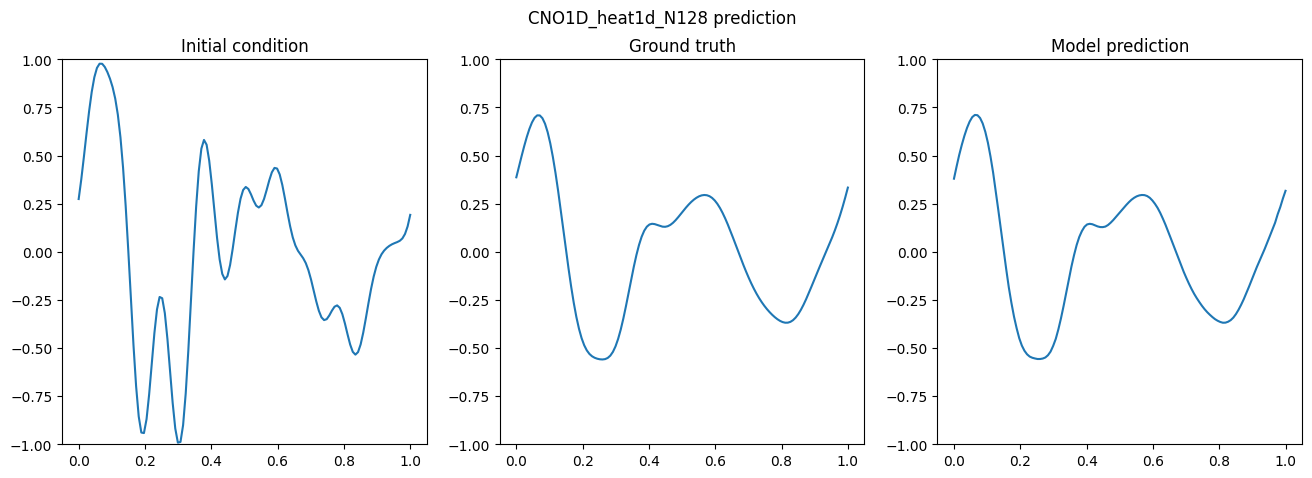

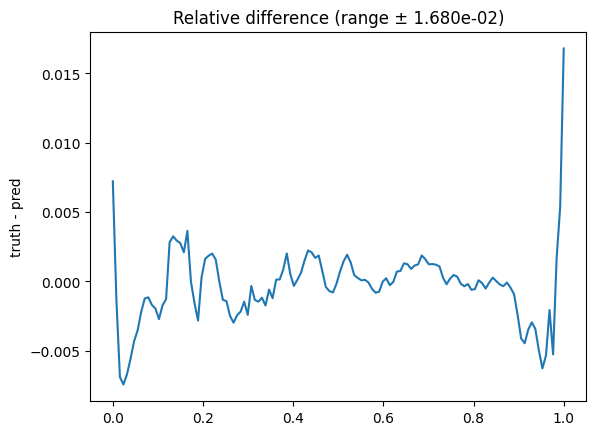

In [32]:
#Test model and visualize predictions on test data

plot_idx = 72
print_all_pred = False

device = next(model.parameters()).device  # robust
pred = torch.zeros(output_function_test.shape)
index = 0
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(input_function_test, output_function_test), batch_size=1, shuffle=False)
with torch.no_grad():
    for x, y in test_loader:
        test_l2 = 0
        x, y = x.to(device), y.to(device)
        #print(x.shape)

        out = model(x).view(-1)
        pred[index] = out

        test_l2 += l(out.view(1, -1), y.view(1, -1)).item()
        if print_all_pred:
            print(index, test_l2)
        index = index + 1

fig, ax = plt.subplots(1,3, figsize = [16,5])
a = np.linspace(0,1,s)  #change 1 to be x_data[last entry spatial dimension]

fig.suptitle(f"{model_name} prediction")

print(input_function_test.shape)
print(input_function_test[plot_idx, :, 0].shape)
print(a.shape)
print(pred.shape)


ax[0].set_title("Initial condition")
ax[0].set_ylim(-1,1)
ax[0].plot(a, input_function_test[plot_idx, 0, :])

ax[1].set_title("Ground truth")
ax[1].set_ylim(-1,1)
ax[1].plot(a, output_function_test[plot_idx, 0, :])

ax[2].set_title("Model prediction")
ax[2].set_ylim(-1,1)
ax[2].plot(a, pred[plot_idx, 0, :])

plt.show()

rel_diff = output_function_test[plot_idx, 0, :] - pred[plot_idx, 0, :]
rel_max = max(rel_diff)

plt.plot(a, rel_diff)
plt.title(f"Relative difference (range ± {rel_max:.3e})")
plt.ylabel("truth - pred")
plt.show()

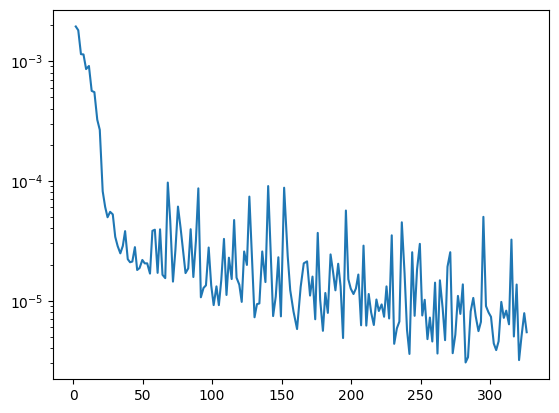

In [31]:
model_time = time_loss[0, :]
model_loss = time_loss[1, :]

plt.plot(model_time, model_loss)
plt.yscale("log")